In [1]:
import pandas as pd
from scipy.special import gamma
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.dates as mdates
from scipy.optimize import minimize_scalar


# Константы

In [2]:
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
INITIAL_BAUXITE = 7 # исходное количество боксита в мельнице, т

# Параметры для расчета объема пульпы в мельнице
FILL_RATE = 0.45  # доля заполнения мельницы
BALL_MASS = 60  # масса мелящих шаров, т
MILL_VOLUME = 36  # объем мельницы, м3
MILL_LENGTH = 4.5 # длина мельницы, м
STEEL_DENSITY = 7800  # плотность стали, кг/м3
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
WATER_DENSITY = 1000 # плотность воды, кг/м3

# -- Для Розина-Раммлера --
D1 = 0.056 # диаметр сита, мм
D2 = 0.16 # диаметр сита, мм

In [3]:
# объём шаров, м3
BALL_VOLUME = BALL_MASS * 1000 / STEEL_DENSITY

# Объём пульпы (боксит+вода+раствор), м3
SLURRY_VOLUME = MILL_VOLUME * FILL_RATE - BALL_VOLUME

# Площадь сечения мельницы, м2
MILL_AREA =  MILL_VOLUME / MILL_LENGTH

# Площадь сечения пульпы, м2
F_SLURRY = SLURRY_VOLUME / MILL_LENGTH

# epsilon для вычисления скорости
EPS = 1-(BALL_VOLUME/MILL_VOLUME)

In [4]:
params = [
    ("BAUXITE_DENSITY", "Плотность боксита", BAUXITE_DENSITY, "кг/м³"),
    ("INITIAL_BAUXITE", "Исходное количество боксита в мельнице", INITIAL_BAUXITE, "т"),
    ("FILL_RATE", "Доля заполнения мельницы", FILL_RATE, "-"),
    ("BALL_MASS", "Масса мелящих шаров", BALL_MASS, "т"),
    ("MILL_VOLUME", "Объем мельницы", MILL_VOLUME, "м³"),
    ("MILL_LENGTH", "Длина мельницы", MILL_LENGTH, "м"),
    ("STEEL_DENSITY", "Плотность стали", STEEL_DENSITY, "кг/м³"),
    ("WATER_DENSITY", "Плотность воды", WATER_DENSITY, "кг/м³"),
    ("D1", "Диаметр сита 1", D1, "мм"),
    ("D2", "Диаметр сита 2", D2, "мм"),
    ("BALL_VOLUME", "Объём шаров", BALL_VOLUME, "м³"),
    ("SLURRY_VOLUME", "Объём пульпы", SLURRY_VOLUME, "м³"),
    ("MILL_AREA", "Площадь сечения мельницы", MILL_AREA, "м²"),
    ("F_SLURRY", "Площадь сечения пульпы", F_SLURRY, "м²"),
    ("EPS", "Коэффициент ε", EPS, "-"),
]

print("=" * 110)
print(f"{'Переменная':<20} {'Описание':<42} {'Значение':<20} {'Ед. изм.':<10}")
print("=" * 110)

for var, comment, value, unit in params:
    if isinstance(value, float):
        value_str = f"{value:.5f}"
    else:
        value_str = str(value)

    print(f"{var:<20} {comment:<42} {value_str:<20} {unit:<10}")
    print("-" * 110)

print("=" * 110)

Переменная           Описание                                   Значение             Ед. изм.  
BAUXITE_DENSITY      Плотность боксита                          2800                 кг/м³     
--------------------------------------------------------------------------------------------------------------
INITIAL_BAUXITE      Исходное количество боксита в мельнице     7                    т         
--------------------------------------------------------------------------------------------------------------
FILL_RATE            Доля заполнения мельницы                   0.45000              -         
--------------------------------------------------------------------------------------------------------------
BALL_MASS            Масса мелящих шаров                        60                   т         
--------------------------------------------------------------------------------------------------------------
MILL_VOLUME          Объем мельницы                             36          

# Предобработка датасета

In [5]:
df = pd.read_csv('industrial_data.csv')
df = pd.DataFrame(df)
df

,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],Q_liquid_mixer13_[m3/h],Q_liquid_mixer14_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],l/s_sliv_hydrocyclone1,...,minus_56_peski_hydrocyclone1_[%],l/s_mill14_unloading,plus_160_mill14_unloading_[%],minus_56_mill14_unloading_[%],l/s_sliv_hydrocyclone2,plus_160_sliv_hydrocyclone2_[%],minus_56_sliv_hydrocyclone2_[%],l/s_peski_hydrocyclone2,plus_160_peski_hydrocyclone2_[%],minus_56_peski_hydrocyclone2_[%]
0,83.7862,08/02/23,11:30÷11:43,49.4,87.0,121.0,2.6,30.71,52.16,4.3,...,11.44,1.9,49.87,25.73,4.4,10.11,64.46,1.1,81.62,2.62
1,72.9909,08/02/23,11:57÷12:00,44.0,79.6,133.0,2.7,22.19,63.92,4.0,...,NaN,2.3,48.71,27.88,4.0,10.42,65.80,NaN,NaN,NaN
2,104.2654,08/02/23,12:20÷12:23,43.0,79.0,132.0,1.9,25.43,60.32,3.1,...,NaN,1.5,50.55,26.62,4.4,5.88,66.78,NaN,NaN,NaN
3,47.7520,09/02/23,16:08÷16:20,46.4,76.7,100.8,4.0,15.79,70.30,6.8,...,34.20,2.4,21.96,48.47,4.7,2.71,77.47,1.9,28.57,45.69
4,56.1883,09/02/23,16:31÷16:36,46.4,76.1,100.7,3.4,22.96,60.90,5.3,...,NaN,3.5,12.11,63.53,5.3,6.04,72.49,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,48.3660,28/09/23,14:30÷14:39,57.4,113.2,171.7,5.5,13.32,63.71,6.3,...,2.80,1.9,35.58,20.36,5.8,1.13,84.59,0.6,53.87,4.46
175,61.9413,02/10/23,15:32÷15:40,57.2,134.3,180.9,4.9,14.10,70.70,7.1,...,16.19,1.9,26.33,37.09,5.1,1.79,72.23,0.4,63.65,1.36
176,101.3303,04/10/23,14:42÷14:50,31.6,115.2,181.5,2.4,23.86,57.00,6.3,...,10.44,1.7,30.27,35.89,11.4,0.01,99.41,3.0,30.59,42.10
177,68.4198,05/10/23,13:50÷14:00,59.4,99.4,159.2,3.6,14.03,64.91,5.3,...,19.72,1.5,37.14,32.21,4.6,3.21,73.11,0.6,66.06,13.37


In [6]:
df.isna().sum()

Q_bauxite_[t/h]                       2
date                                  0
time                                  0
Q_liquid_mill13_[m3/h]                0
Q_liquid_mixer13_[m3/h]               0
Q_liquid_mixer14_[m3/h]               0
l/s_mill13_unloading                  0
plus_160_mill13_unloading_[%]         0
minus_56_mill13_unloading_[%]         0
l/s_sliv_hydrocyclone1                0
plus_160_sliv_hydrocyclone1_[%]       0
minus_56_sliv_hydrocyclone1_[%]       0
l/s_peski_hydrocyclone1             109
plus_160_peski_hydrocyclone1_[%]    109
minus_56_peski_hydrocyclone1_[%]    109
l/s_mill14_unloading                  1
plus_160_mill14_unloading_[%]         1
minus_56_mill14_unloading_[%]         1
l/s_sliv_hydrocyclone2                1
plus_160_sliv_hydrocyclone2_[%]       1
minus_56_sliv_hydrocyclone2_[%]       1
l/s_peski_hydrocyclone2             109
plus_160_peski_hydrocyclone2_[%]    109
minus_56_peski_hydrocyclone2_[%]    109
dtype: int64

In [7]:
df.dtypes

Q_bauxite_[t/h]                     float64
date                                    str
time                                    str
Q_liquid_mill13_[m3/h]              float64
Q_liquid_mixer13_[m3/h]             float64
Q_liquid_mixer14_[m3/h]             float64
l/s_mill13_unloading                float64
plus_160_mill13_unloading_[%]       float64
minus_56_mill13_unloading_[%]       float64
l/s_sliv_hydrocyclone1              float64
plus_160_sliv_hydrocyclone1_[%]     float64
minus_56_sliv_hydrocyclone1_[%]     float64
l/s_peski_hydrocyclone1             float64
plus_160_peski_hydrocyclone1_[%]    float64
minus_56_peski_hydrocyclone1_[%]    float64
l/s_mill14_unloading                float64
plus_160_mill14_unloading_[%]       float64
minus_56_mill14_unloading_[%]       float64
l/s_sliv_hydrocyclone2              float64
plus_160_sliv_hydrocyclone2_[%]     float64
minus_56_sliv_hydrocyclone2_[%]     float64
l/s_peski_hydrocyclone2             float64
plus_160_peski_hydrocyclone2_[%]

Перевод даты в нужный формат данных

In [8]:
df['date'] = pd.to_datetime(df['date'])

/var/folders/pw/9v35zrks1gj89m9hgtttxv1c0000gn/T/ipykernel_36860/3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


Добавление среднего времени взятия боксита

In [9]:
# разделяем колонку на две: начало и конец
times = df['time'].str.split('÷', expand=True)

# переводим в формат Timedelta (длительность от начала суток)
start = pd.to_timedelta(times[0] + ':00')
end = pd.to_timedelta(times[1] + ':00')

# считаем среднее значение Timedelta
avg_delta = (start + end) / 2

# прибавляем к нужной дате (например, 2023-02-08)
df['average_time'] = pd.to_datetime(df['date']) + avg_delta

In [10]:
df

,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],Q_liquid_mixer13_[m3/h],Q_liquid_mixer14_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],l/s_sliv_hydrocyclone1,...,l/s_mill14_unloading,plus_160_mill14_unloading_[%],minus_56_mill14_unloading_[%],l/s_sliv_hydrocyclone2,plus_160_sliv_hydrocyclone2_[%],minus_56_sliv_hydrocyclone2_[%],l/s_peski_hydrocyclone2,plus_160_peski_hydrocyclone2_[%],minus_56_peski_hydrocyclone2_[%],average_time
0,83.7862,2023-08-02,11:30÷11:43,49.4,87.0,121.0,2.6,30.71,52.16,4.3,...,1.9,49.87,25.73,4.4,10.11,64.46,1.1,81.62,2.62,2023-08-02 11:36:30
1,72.9909,2023-08-02,11:57÷12:00,44.0,79.6,133.0,2.7,22.19,63.92,4.0,...,2.3,48.71,27.88,4.0,10.42,65.80,NaN,NaN,NaN,2023-08-02 11:58:30
2,104.2654,2023-08-02,12:20÷12:23,43.0,79.0,132.0,1.9,25.43,60.32,3.1,...,1.5,50.55,26.62,4.4,5.88,66.78,NaN,NaN,NaN,2023-08-02 12:21:30
3,47.7520,2023-09-02,16:08÷16:20,46.4,76.7,100.8,4.0,15.79,70.30,6.8,...,2.4,21.96,48.47,4.7,2.71,77.47,1.9,28.57,45.69,2023-09-02 16:14:00
4,56.1883,2023-09-02,16:31÷16:36,46.4,76.1,100.7,3.4,22.96,60.90,5.3,...,3.5,12.11,63.53,5.3,6.04,72.49,NaN,NaN,NaN,2023-09-02 16:33:30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,48.3660,2023-09-28,14:30÷14:39,57.4,113.2,171.7,5.5,13.32,63.71,6.3,...,1.9,35.58,20.36,5.8,1.13,84.59,0.6,53.87,4.46,2023-09-28 14:34:30
175,61.9413,2023-02-10,15:32÷15:40,57.2,134.3,180.9,4.9,14.10,70.70,7.1,...,1.9,26.33,37.09,5.1,1.79,72.23,0.4,63.65,1.36,2023-02-10 15:36:00
176,101.3303,2023-04-10,14:42÷14:50,31.6,115.2,181.5,2.4,23.86,57.00,6.3,...,1.7,30.27,35.89,11.4,0.01,99.41,3.0,30.59,42.10,2023-04-10 14:46:00
177,68.4198,2023-05-10,13:50÷14:00,59.4,99.4,159.2,3.6,14.03,64.91,5.3,...,1.5,37.14,32.21,4.6,3.21,73.11,0.6,66.06,13.37,2023-05-10 13:55:00


Для анализа работы 13 мельницы возьмем данные для неё

In [11]:
df_mill13 = df[['Q_bauxite_[t/h]', 'date', 'time', 'Q_liquid_mill13_[m3/h]', 'l/s_mill13_unloading', 'plus_160_mill13_unloading_[%]', 'minus_56_mill13_unloading_[%]', 'average_time']]

In [12]:
df_mill13

,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time
0,83.7862,2023-08-02,11:30÷11:43,49.4,2.6,30.71,52.16,2023-08-02 11:36:30
1,72.9909,2023-08-02,11:57÷12:00,44.0,2.7,22.19,63.92,2023-08-02 11:58:30
2,104.2654,2023-08-02,12:20÷12:23,43.0,1.9,25.43,60.32,2023-08-02 12:21:30
3,47.7520,2023-09-02,16:08÷16:20,46.4,4.0,15.79,70.30,2023-09-02 16:14:00
4,56.1883,2023-09-02,16:31÷16:36,46.4,3.4,22.96,60.90,2023-09-02 16:33:30
...,...,...,...,...,...,...,...,...
174,48.3660,2023-09-28,14:30÷14:39,57.4,5.5,13.32,63.71,2023-09-28 14:34:30
175,61.9413,2023-02-10,15:32÷15:40,57.2,4.9,14.10,70.70,2023-02-10 15:36:00
176,101.3303,2023-04-10,14:42÷14:50,31.6,2.4,23.86,57.00,2023-04-10 14:46:00
177,68.4198,2023-05-10,13:50÷14:00,59.4,3.6,14.03,64.91,2023-05-10 13:55:00


In [13]:
# перевод процентов в доли, 
# доля частиц, ПРОШЕДШИХ через сито

# выход мельницы 13
df_mill13["P56"] = df['minus_56_mill13_unloading_[%]'] / 100 # d1
df_mill13["P160"] = 1 - df['plus_160_mill13_unloading_[%]'] / 100 # d2

Удаление выбросов, где df_mill13["P56"] >= df_mill13["P160"]

In [14]:
bad_rows = df_mill13[df_mill13["P56"] >= df_mill13["P160"]]
print(bad_rows)

Empty DataFrame
Columns: [Q_bauxite_[t/h], date, time, Q_liquid_mill13_[m3/h], l/s_mill13_unloading, plus_160_mill13_unloading_[%], minus_56_mill13_unloading_[%], average_time, P56, P160]
Index: []


## Визуализация

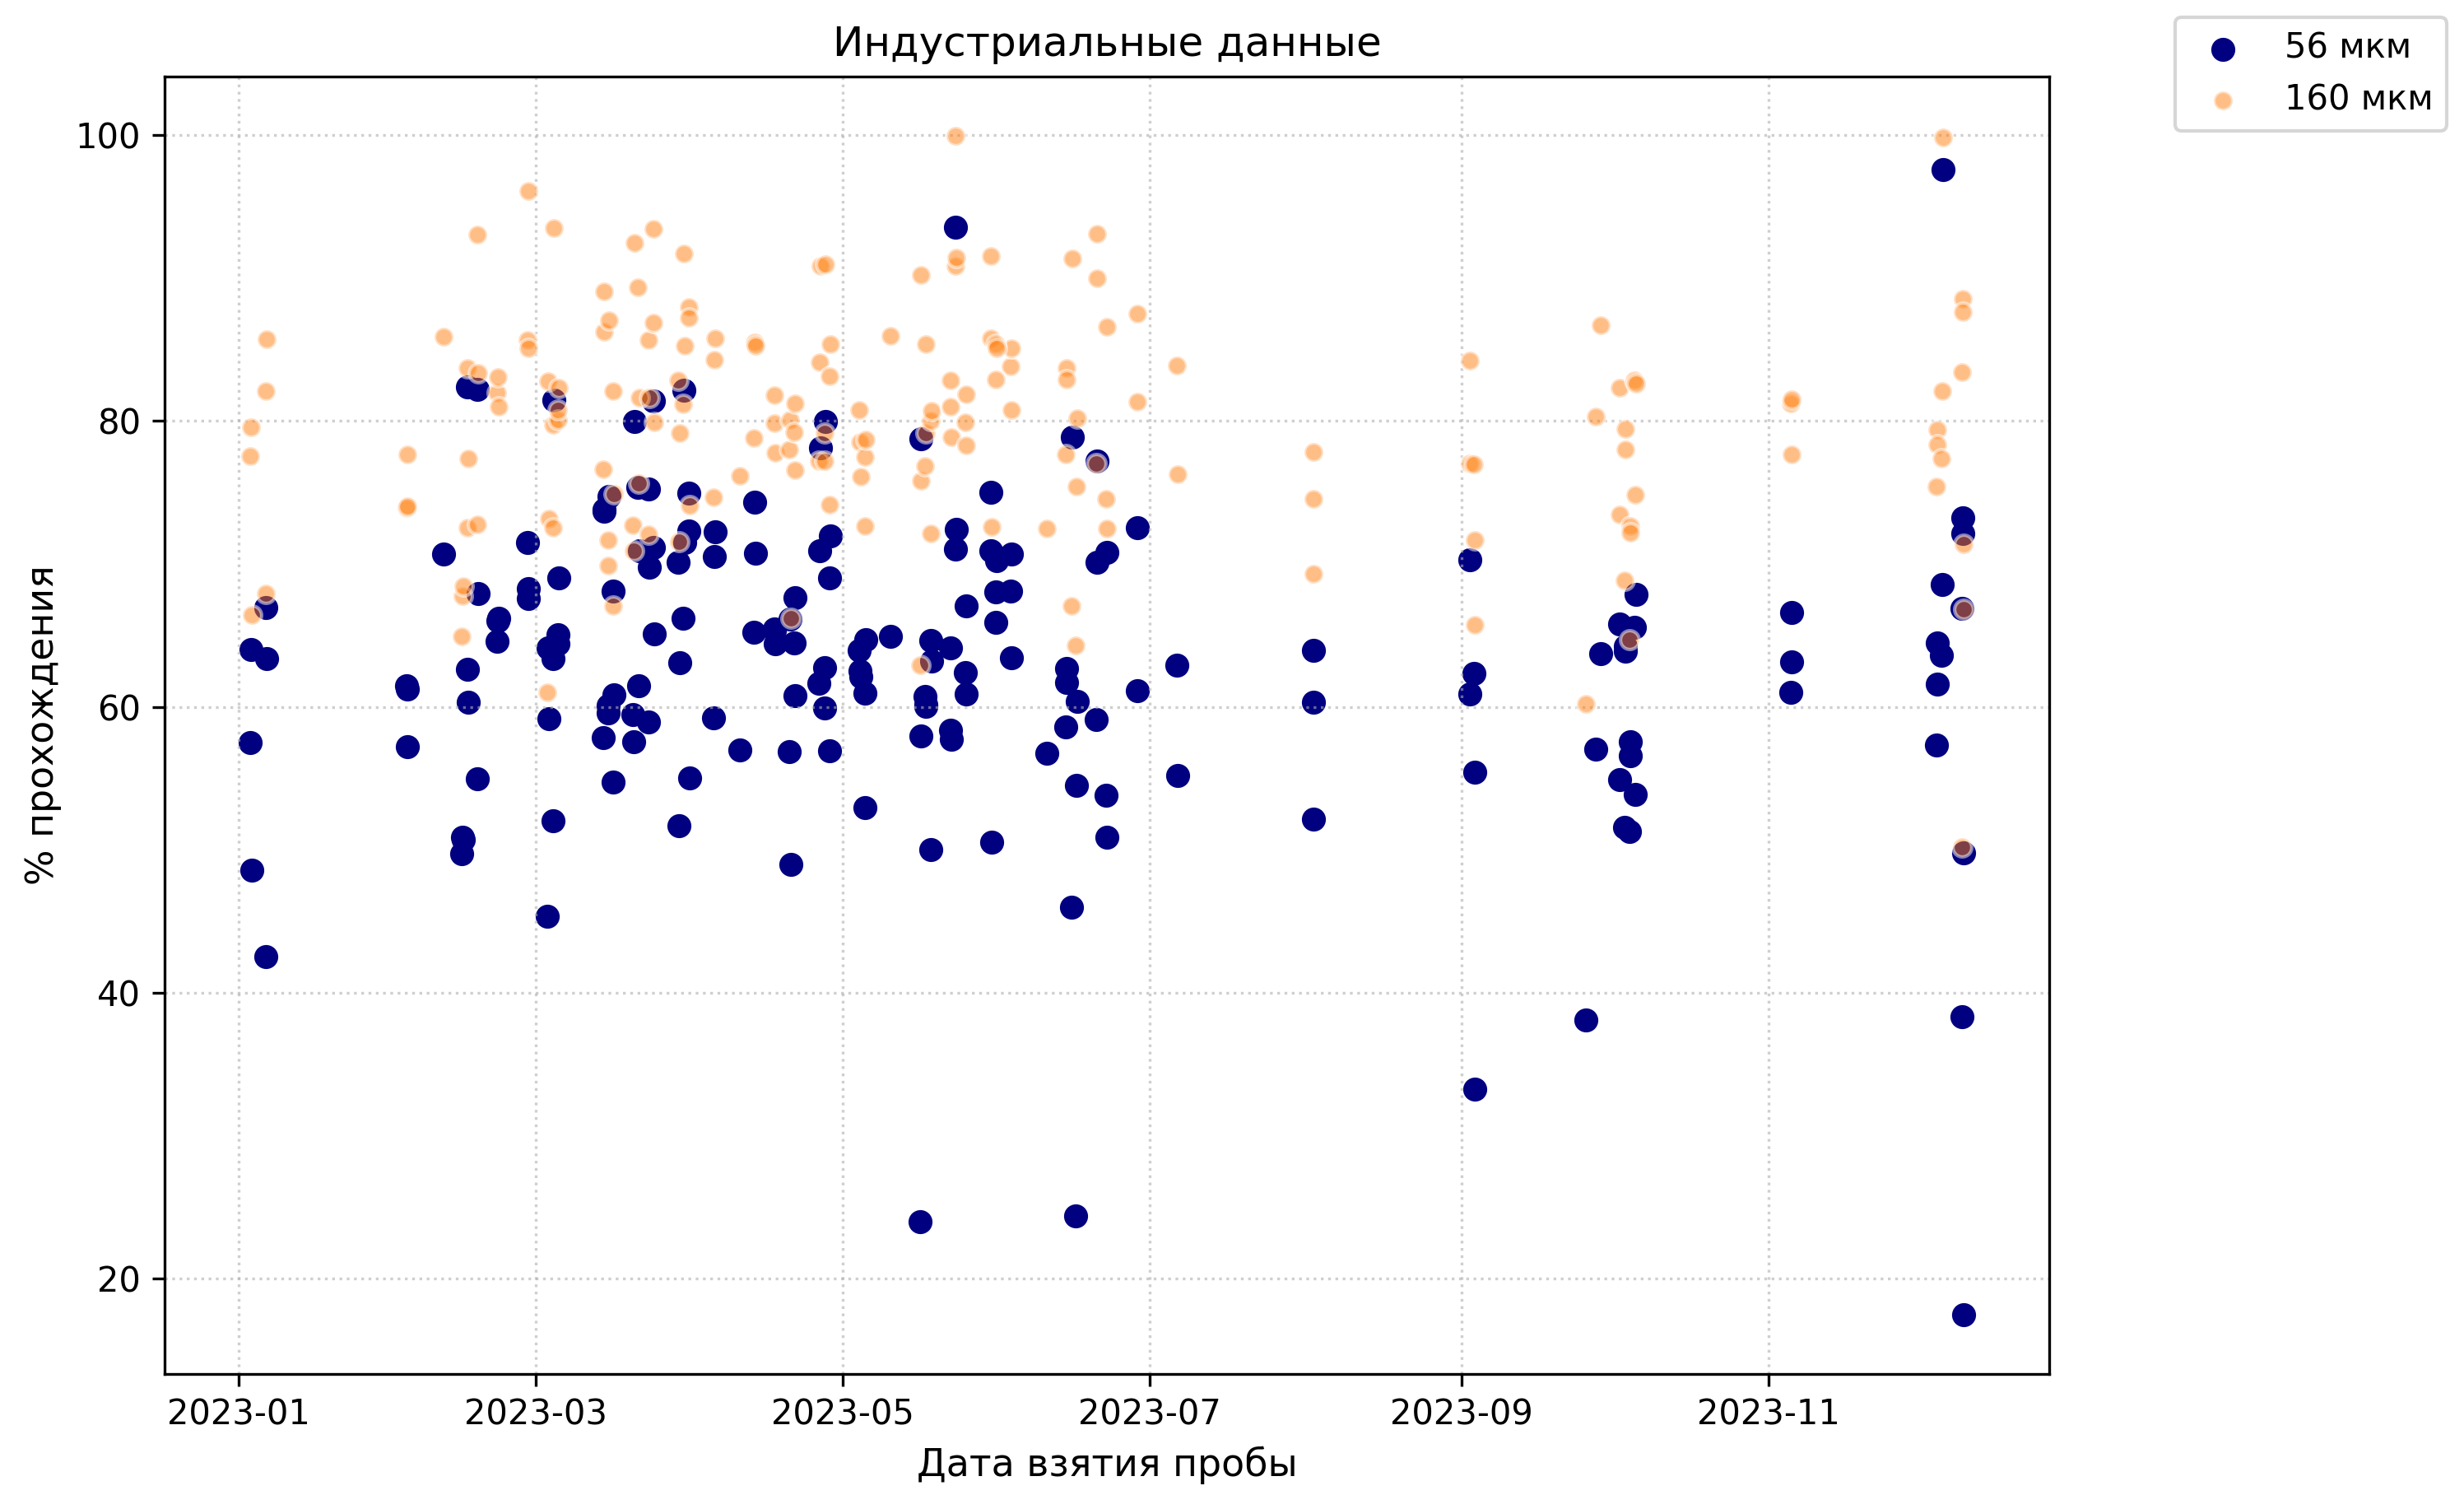

In [21]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

ax.scatter(df_mill13['average_time'], df_mill13['P56']*100, label='56 мкм', color='navy')
ax.scatter(df_mill13['average_time'], df_mill13['P160']*100, color='tab:orange', alpha=0.5, s=30, 
           edgecolors='white', label='160 мкм', zorder=2)

# Оформление осей
ax.set_xlabel('Дата взятия пробы', fontsize=11)
ax.set_ylabel('% прохождения', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6) 

# Легенда: выносим за пределы графика вправо, чтобы не перекрывать данные
fig.legend(loc='upper right')

# Автоматическая подгонка, чтобы легенда влезла
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.title('Индустриальные данные')

plt.show()

# Расчёт удельной поверхности

Формула Розина-Раммлера для частиц, прошедших через сито:<br>

$R(d) = 1 - \exp(-(d/de)^n)$

## Нахождение глобального оптимального n

In [15]:
def objective(n):
    right_side = np.log(1 - df_mill13['P56']) / np.log(1 - df_mill13['P160'])
    left_side = (D1 / D2) ** n

    error = np.sum((left_side - right_side) ** 2)
    return error


result = minimize_scalar(
    objective,
    bounds=(0.1, 3),
    method="bounded"
)

N_OPT = result.x
print("Оптимальное n =", N_OPT)

Оптимальное n = 0.4611685778753849


## Нахождение de и S

In [16]:
# de для каждой пробы
df_mill13["de_[mm]"] = D1 / ((-np.log(1 - df_mill13["P56"])) ** (1 / N_OPT))

# S для каждой пробы
df_mill13["S_[m2/kg]"] = 6 / (BAUXITE_DENSITY * df_mill13["de_[mm]"] * 1e-3) * gamma(1 - 1 / N_OPT)

In [17]:
df_mill13.describe()

,Q_bauxite_[t/h],date,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
count,177.000000,179,179.000000,179.000000,179.000000,179.000000,179,179.000000,179.000000,179.000000,179.000000
mean,69.722731,2023-05-21 22:55:38.547486,49.626816,3.615084,20.449385,62.972737,2023-05-22 10:59:31.005586,0.629727,0.795506,0.084654,277.906877
min,29.085400,2023-01-03 00:00:00,31.600000,1.300000,0.040000,17.470000,2023-01-03 08:42:30,0.174700,0.502000,0.003249,6.138922
25%,56.860000,2023-03-20 00:00:00,46.800000,2.900000,15.320000,57.780000,2023-03-20 12:37:00,0.577800,0.747500,0.038835,159.442067
50%,68.048500,2023-05-04 00:00:00,49.400000,3.500000,20.090000,63.410000,2023-05-04 08:53:00,0.634100,0.799100,0.055350,222.439150
75%,79.760300,2023-06-20 00:00:00,52.050000,4.200000,25.250000,69.395000,2023-06-20 12:48:45,0.693950,0.846800,0.077221,317.188927
max,155.165900,2023-12-09 00:00:00,69.900000,6.600000,49.800000,97.570000,2023-12-09 17:15:00,0.975700,0.999600,2.005580,3789.857095
std,17.973246,NaN,5.080615,0.866445,7.713356,10.706773,NaN,0.107068,0.077134,0.175433,323.816791


Text(0.5, 0, 'Номер пробы')

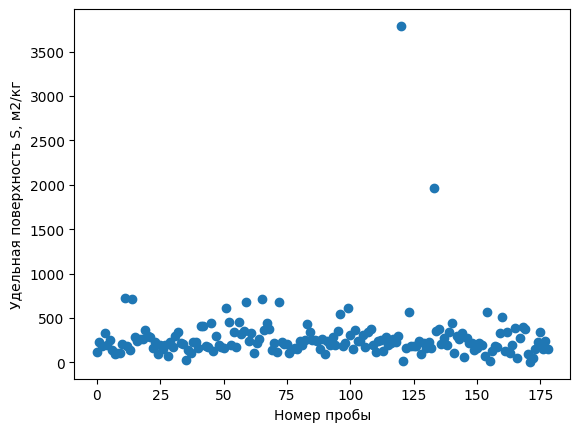

In [18]:
plt.scatter(range(len(df_mill13)), df_mill13['S_[m2/kg]'])
plt.ylabel('Удельная поверхность S, м2/кг')
plt.xlabel('Номер пробы')

## Очистка выбросов

In [19]:
Q1 = df_mill13["S_[m2/kg]"].quantile(0.25)
Q3 = df_mill13["S_[m2/kg]"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

df_clean = df_mill13[(df_mill13["S_[m2/kg]"] >= lower) & (df_mill13["S_[m2/kg]"] <= upper)]

print("Удалено строк:", len(df_mill13) - len(df_clean))

Удалено строк: 2


Text(0.5, 0, 'Номер пробы')

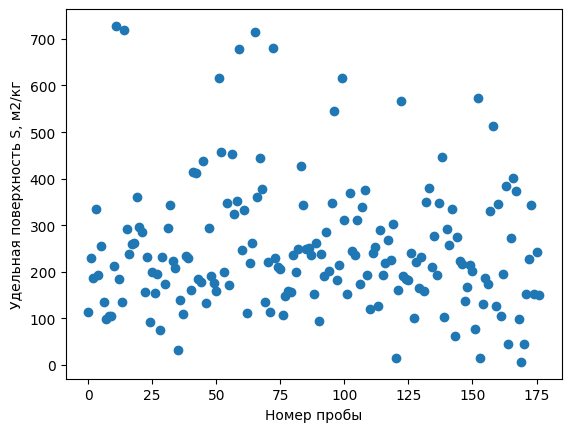

In [20]:
plt.scatter(range(len(df_clean)), df_clean['S_[m2/kg]'])
plt.ylabel('Удельная поверхность S, м2/кг')
plt.xlabel('Номер пробы')

# Сохранение результатов

In [21]:
df_clean.to_csv('prepared_data_mill13.csv')